In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer
from sklearn.compose import TransformedTargetRegressor

In [15]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V3.csv')
X = df.drop('price_per_m2', axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
def gap_scorer(estimator, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    test_r2_scores = []
    gaps = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        estimator.fit(X_train_fold, y_train_fold)
        train_r2 = r2_score(y_train_fold, estimator.predict(X_train_fold))
        val_r2 = r2_score(y_val, estimator.predict(X_val))
        
        test_r2_scores.append(val_r2)
        gaps.append(abs(train_r2 - val_r2))
    
    # 80% weight on test R2, 20% penalty for gaps
    return (0.8 * np.mean(test_r2_scores)) - (0.2 * np.mean(gaps))

In [17]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', BayesianRidge())
])

In [18]:
param_grid = {
    'model__alpha_1': [1e-6, 1e-5],
    'model__alpha_2': [1e-6, 1e-5],
    'model__lambda_1': [1e-3, 1e-2],  # Stronger regularization
    'model__lambda_2': [1e-3, 1e-2],
    'model__max_iter': [200, 300],
    'poly__degree': [2, 3],  # Test degree 2 and 3 polynomials
    'poly__interaction_only': [False]  # Include squared terms
}

In [19]:
search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=make_scorer(gap_scorer, greater_is_better=True),
    cv=5,
    n_jobs=-1,
    verbose=2
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('model', BayesianRidge())]),
             n_jobs=-1,
             param_grid={'model__alpha_1': [1e-06, 1e-05],
                         'model__alpha_2': [1e-06, 1e-05],
                         'model__lambda_1': [0.001, 0.01],
                         'model__lambda_2': [0.001, 0.01],
                         'model__max_iter': [200, 300], 'poly__degree': [2, 3],
                         'poly__interaction_only': [False]},
             scoring=make_scorer(gap_scorer, response_method='predict'),
             verbose=2)

In [20]:
best_model = search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f"\nBest Parameters: {search.best_params_}")
print(f"Train R2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R2: {r2_score(y_test, y_test_pred):.4f}")
print(f"R2 Gap: {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.4f}")


Best Parameters: {'model__alpha_1': 1e-06, 'model__alpha_2': 1e-06, 'model__lambda_1': 0.001, 'model__lambda_2': 0.001, 'model__max_iter': 200, 'poly__degree': 2, 'poly__interaction_only': False}
Train R2: 0.9142
Test R2: 0.9107
R2 Gap: 0.0036


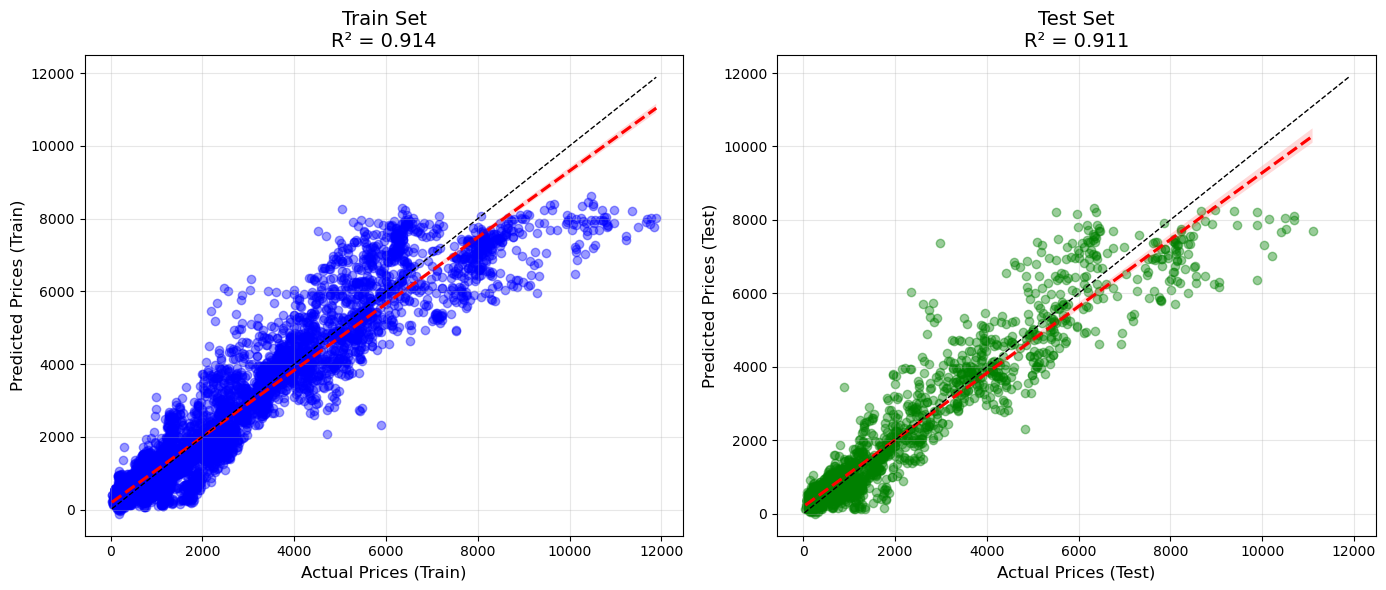

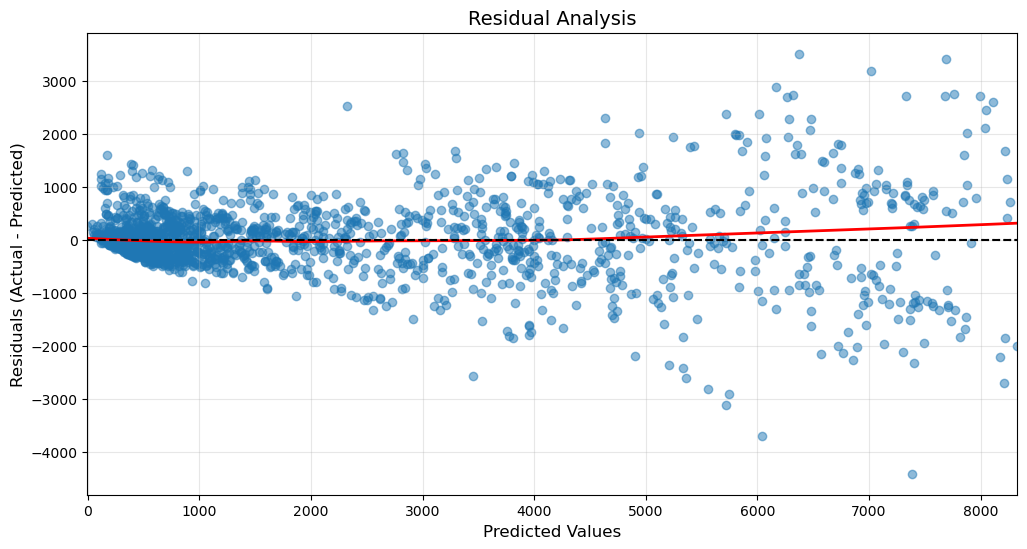

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Training set results
plt.subplot(1, 2, 1)
sns.regplot(x=y_train, y=y_train_pred, 
            scatter_kws={'alpha':0.4, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
plt.xlabel('Actual Prices (Train)', fontsize=12)
plt.ylabel('Predicted Prices (Train)', fontsize=12)
plt.title(f'Train Set\nR² = {r2_score(y_train, y_train_pred):.3f}', fontsize=14)
plt.grid(alpha=0.3)

# Subplot 2: Test set results
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_test_pred, 
            scatter_kws={'alpha':0.4, 'color':'green'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
plt.xlabel('Actual Prices (Test)', fontsize=12)
plt.ylabel('Predicted Prices (Test)', fontsize=12)
plt.title(f'Test Set\nR² = {r2_score(y_test, y_test_pred):.3f}', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(12, 6))
residuals = y_test - y_test_pred
sns.residplot(x=y_test_pred, y=residuals, 
              lowess=True,
              scatter_kws={'alpha':0.5},
              line_kws={'color':'red', 'lw':2})
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Analysis', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.metrics import mean_squared_error
import numpy as np

# For RMSE calculation:
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# For MSE calculation:
mse = mean_squared_error(y_test, y_test_pred)


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    max_error,
    explained_variance_score
)


In [24]:
def print_regression_metrics(y_true, y_pred, set_name="Test"):
    """Prints all key regression metrics in a formatted table"""
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    medae = median_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    rel_mae = mae / np.mean(y_true)
    within_10 = np.mean(np.abs((y_true - y_pred)/y_true) < 0.10) * 100
    
    # Adjusted R² calculation (assuming X is available)
    try:
        n = len(y_true)
        p = X.shape[1] if hasattr(X, 'shape') else len(X[0])
        adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    except:
        adj_r2 = None
    
    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'Adjusted R²': adj_r2,
        'MAPE': mape,
        'MedianAE': medae,
        'MaxError': max_err,
        'Explained Variance': evs,
        'Relative MAE': rel_mae,
        'Within 10%': within_10
    }
    
    print(f"\n{set_name} Set Performance:")
    print("="*50)
    print(f"{'Metric':<20} {'Value':<20} {'Ideal':<10}")
    print("-"*50)
    
    for name, value in metrics.items():
        if value is None:
            continue
        if name in ['R²', 'Adjusted R²', 'Explained Variance']:
            print(f"{name:<20} {value:.4f}           {'1.0'}")
        elif name in ['MAE', 'MSE', 'RMSE', 'MedianAE', 'MaxError']:
            print(f"{name:<20} {value:.2f}           {'0.0'}")
        elif '%' in name:
            print(f"{name:<20} {value:.1f}%          {'100%'}")
        else:
            print(f"{name:<20} {value:.4f}           {'-'}")
    
    print("="*50)

In [25]:
# Assuming you have:
# X_train, X_test, y_train, y_test
# model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print_regression_metrics(y_train, y_train_pred, "Train")
print_regression_metrics(y_test, y_test_pred, "Test")


Train Set Performance:
Metric               Value                Ideal     
--------------------------------------------------
MAE                  441.52           0.0
MSE                  453780.80           0.0
RMSE                 673.63           0.0
R²                   0.9142           1.0
Adjusted R²          0.9141           1.0
MAPE                 45.7547           -
MedianAE             265.87           0.0
MaxError             4067.42           0.0
Explained Variance   0.9142           1.0
Relative MAE         0.2134           -
Within 10%           22.9%          100%

Test Set Performance:
Metric               Value                Ideal     
--------------------------------------------------
MAE                  447.22           0.0
MSE                  462590.65           0.0
RMSE                 680.14           0.0
R²                   0.9107           1.0
Adjusted R²          0.9099           1.0
MAPE                 43.8874           -
MedianAE             281.57  

In [26]:
import joblib
joblib.dump(best_model, "../../../models/bayesian_ridge/bayesian_ridge_model_label_v2.joblib")

['../../../models/bayesian_ridge/bayesian_ridge_model_label_v2.joblib']